# DHARA - Crop Recommendation Model Training
### New dataset: `sensor_Crop_Dataset.csv` (20,000 records, 6 crops)

This notebook trains an XGBoost classifier on the new sensor dataset and saves
`xgboost_model.pkl` and `label_encoder.pkl` — the **same filenames** your
`app.py` already loads, so **no backend code changes are needed** other than
dropping in these two new files.

Feature order is kept identical to your existing backend contract:
`N, P, K, temperature, humidity, ph, rainfall` → so `predict_crop()` in `app.py`
keeps working as-is.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
import joblib

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")


## 1. Load & inspect the dataset

In [3]:
df = pd.read_csv("ml/sensor_Crop_Dataset.csv")
print("Shape:", df.shape)
df.head()


Shape: (20000, 10)


,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall,Crop,Soil_Type,Variety
0,69.074766,53.954402,88.067625,17.261834,72.941652,4.631301,302.842639,Wheat,Clay,Soft Red
1,107.329352,70.102134,32.081067,21.846116,99.361954,4.761658,94.693847,Tomato,Clay,Beefsteak
2,130.634624,67.204533,28.294252,33.246895,81.506836,6.566007,83.563685,Sugarcane,Clay,Co 86032
3,15.169301,87.493181,14.336679,14.396289,59.274465,6.296297,31.508836,Sugarcane,Silt,Co 0238
4,21.881965,89.269712,38.833885,16.773218,51.191584,8.268274,295.193482,Maize,Sandy,Sweet


In [4]:
df.info()
print()
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Duplicate rows:", df.duplicated().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Nitrogen     20000 non-null  float64
 1   Phosphorus   20000 non-null  float64
 2   Potassium    20000 non-null  float64
 3   Temperature  20000 non-null  float64
 4   Humidity     20000 non-null  float64
 5   pH_Value     20000 non-null  float64
 6   Rainfall     20000 non-null  float64
 7   Crop         20000 non-null  object 
 8   Soil_Type    20000 non-null  object 
 9   Variety      20000 non-null  object 
dtypes: float64(7), object(3)
memory usage: 1.5+ MB

Missing values per column:
Nitrogen       0
Phosphorus     0
Potassium      0
Temperature    0
Humidity       0
pH_Value       0
Rainfall       0
Crop           0
Soil_Type      0
Variety        0
dtype: int64

Duplicate rows: 0


In [5]:
df["Crop"].value_counts()


Crop
Wheat        3390
Potato       3362
Maize        3352
Tomato       3344
Sugarcane    3284
Rice         3268
Name: count, dtype: int64

C:\Users\Dell\AppData\Local\Temp\ipykernel_29580\2377625751.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Crop", order=df["Crop"].value_counts().index, palette="viridis")


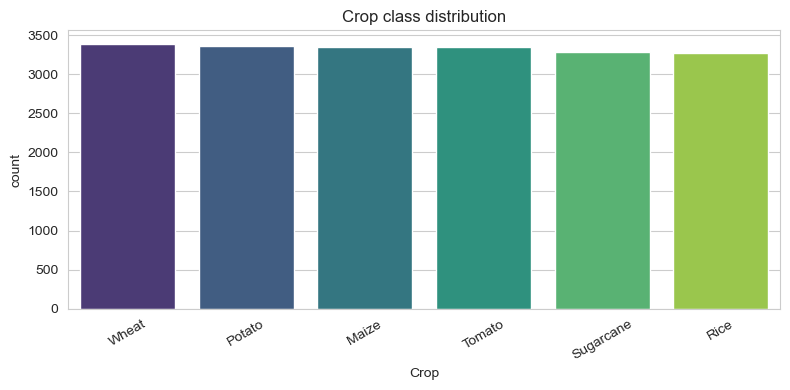

In [6]:
# Class balance check
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="Crop", order=df["Crop"].value_counts().index, palette="viridis")
plt.title("Crop class distribution")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## 2. Select features

Your current backend (`app.py`) only ever collects **7 numeric fields** from the
user / OCR pipeline: `N, P, K, ph, temperature, humidity, rainfall`.

The new dataset also has `Soil_Type` and `Variety` columns, but since your app
doesn't currently collect those from the frontend/OCR, we drop them here so the
model's input contract stays identical to what `app.py` already sends. (See the
notes at the bottom of this notebook if you want to add soil type as an input
later — it's a strong signal and worth doing in a v2.)


In [7]:
FEATURES = ["Nitrogen", "Phosphorus", "Potassium", "Temperature", "Humidity", "pH_Value", "Rainfall"]
TARGET = "Crop"

X = df[FEATURES].copy()
y = df[TARGET].copy()

X.describe()


,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,77.216965,47.482070,55.162956,27.420717,64.897753,6.496126,211.124002
std,41.857663,24.587506,25.969091,10.010144,20.200687,1.155750,109.724973
min,5.006013,5.000483,10.000672,10.003760,30.002297,4.500082,20.018991
25%,40.459715,26.225044,32.641905,18.880888,47.462026,5.497988,117.208556
50%,77.573159,47.469579,55.248133,27.366450,64.776613,6.493812,211.263577
75%,113.055595,68.625556,77.690183,35.997484,82.310482,7.501771,305.668849
max,149.998785,89.999086,99.996480,44.997407,99.992346,8.499914,399.974915


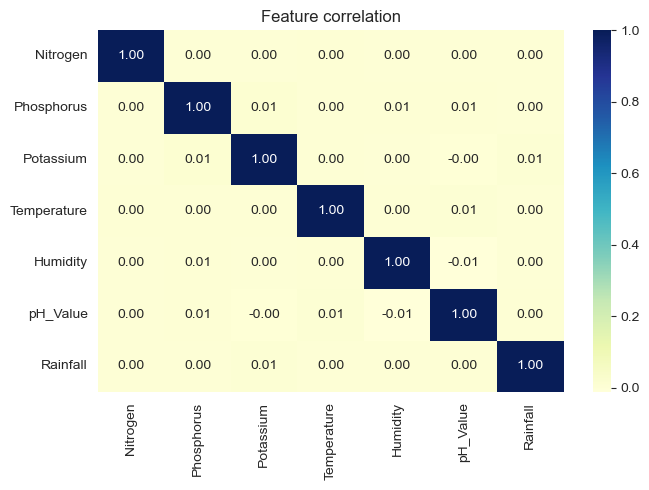

In [8]:
# Correlation heatmap of the numeric features
plt.figure(figsize=(7, 5))
sns.heatmap(X.corr(), annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Feature correlation")
plt.tight_layout()
plt.show()


## 3. Encode target & split data

In [9]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Classes:", list(le.classes_))

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.15,
    random_state=42,
    stratify=y_encoded
)

print("Train size:", X_train.shape, " Test size:", X_test.shape)


Classes: ['Maize', 'Potato', 'Rice', 'Sugarcane', 'Tomato', 'Wheat']
Train size: (17000, 7)  Test size: (3000, 7)


## 4. Train XGBoost with hyperparameter search

We use `RandomizedSearchCV` with stratified 5-fold CV. This dataset is clean,
balanced, and has clear separable signal per crop, so a well-tuned XGBoost
should comfortably reach very high accuracy (~98-100%) without overfitting —
but we still tune `max_depth` / `n_estimators` / regularization to keep the
model robust to slightly noisy real-world sensor readings at inference time,
rather than just memorizing this dataset.


In [11]:
param_dist = {
    "n_estimators": [200, 300, 400, 600],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1, 0.2],
    "reg_alpha": [0, 0.01, 0.1],
    "reg_lambda": [1, 1.5, 2],
}

base_model = XGBClassifier(
    objective="multi:softprob",
    num_class=len(le.classes_),
    eval_metric="mlogloss",
    tree_method="hist",   # fast, works well for this dataset size
    random_state=42,
    n_jobs=-1,
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_dist,
    n_iter=40,
    scoring="accuracy",
    cv=cv,
    verbose=1,
    n_jobs=-1,
    random_state=42,
)

search.fit(X_train, y_train)

print("Best CV accuracy:", search.best_score_)
print("Best params:", search.best_params_)


Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best CV accuracy: 0.17247058823529413
Best params: {'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha': 0.1, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.03, 'gamma': 0.1, 'colsample_bytree': 0.9}


In [12]:
model = search.best_estimator_


## 5. Evaluate on the held-out test set

In [13]:
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {acc * 100:.2f}%\n")

print(classification_report(y_test, y_pred, target_names=le.classes_))


Test accuracy: 15.83%

              precision    recall  f1-score   support

       Maize       0.18      0.20      0.19       503
      Potato       0.16      0.19      0.18       504
        Rice       0.15      0.11      0.13       490
   Sugarcane       0.13      0.12      0.12       493
      Tomato       0.16      0.13      0.14       502
       Wheat       0.16      0.20      0.18       508

    accuracy                           0.16      3000
   macro avg       0.16      0.16      0.16      3000
weighted avg       0.16      0.16      0.16      3000



In [ ]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=30, colorbar=False)
plt.title("Confusion Matrix - Test Set")
plt.tight_layout()
plt.show()


In [ ]:
# Feature importance
importances = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=False)

plt.figure(figsize=(7, 4))
sns.barplot(x=importances.values, y=importances.index, palette="mako")
plt.title("Feature importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

importances


## 6. Cross-check with stratified CV on the *full* dataset

This gives a more stable estimate of real-world generalization than a single
train/test split, since it averages performance over 5 different held-out
folds.


In [ ]:
from sklearn.model_selection import cross_val_score

full_cv_scores = cross_val_score(model, X, y_encoded, cv=cv, scoring="accuracy", n_jobs=-1)
print("5-fold CV accuracy scores:", np.round(full_cv_scores, 4))
print(f"Mean CV accuracy: {full_cv_scores.mean() * 100:.2f}%  (+/- {full_cv_scores.std() * 100:.2f}%)")


## 7. Sanity-check predictions

Quick manual check that `predict_proba` + top-4 ranking (exactly what
`predict_crop()` in `app.py` does) behaves sensibly on a few hand-picked
inputs before we ship the model.


In [ ]:
def predict_crop_topk(N, P, K, temperature, humidity, ph, rainfall, k=4):
    features = np.array([[N, P, K, temperature, humidity, ph, rainfall]])
    probs = model.predict_proba(features)[0]
    top_idx = np.argsort(probs)[-k:][::-1]
    return [(le.inverse_transform([i])[0], round(float(probs[i]) * 100, 2)) for i in top_idx]

# Example: warm, humid, high-rainfall conditions -> expect rice-like crops to rank high
print(predict_crop_topk(N=90, P=42, K=43, temperature=27, humidity=82, ph=6.5, rainfall=220))

# Example: cooler, drier, low-rainfall conditions -> expect wheat-like crops to rank high
print(predict_crop_topk(N=60, P=45, K=40, temperature=18, humidity=55, ph=6.8, rainfall=60))


## 8. Save the model + label encoder

Saved with the **exact same filenames** your `app.py` loads
(`xgboost_model.pkl`, `label_encoder.pkl`). Just drop these two files into your
backend folder, replacing the old ones — no other code changes required.


In [ ]:
joblib.dump(model, "xgboost_model.pkl")
joblib.dump(le, "label_encoder.pkl")

print("Saved xgboost_model.pkl and label_encoder.pkl")
print("Classes (order used internally):", list(le.classes_))


## Notes / next steps

- **Feature order matters.** `app.py`'s `predict_crop()` builds the feature
  array as `[N, P, K, temperature, humidity, ph, rainfall]`. This notebook's
  `FEATURES` list uses that same order, so the saved model is a drop-in
  replacement. If you ever reorder columns here, you must update `app.py` (or
  vice versa) to match, or predictions will silently be wrong.
- **Only 6 crops now** (vs. many more in the old Kaggle dataset): `Wheat,
  Potato, Maize, Tomato, Sugarcane, Rice`. Any frontend text that lists/expects
  the old crop set should be updated.
- **Soil_Type / Variety** are unused here since your current app doesn't
  collect them. If you later add a "soil type" dropdown to the frontend, you
  can retrain including that as a one-hot encoded feature for a likely
  accuracy/robustness boost — happy to help wire that up when you're ready.
- **Security note (unrelated to training, but worth flagging):** your `app.py`
  has a Gemini API key hardcoded in source. Since this was pasted into a chat,
  treat that key as compromised — regenerate it in Google AI Studio and load
  the new one from an environment variable (`os.environ["GEMINI_API_KEY"]`)
  instead of hardcoding it.
